# Exercício:

## 01 – Importe o .csv utilizado no exercício 1 da aula 13 e instancie um objeto da classe DataFrame. Busque no GenBank do NCBI, a sequência aminoacídica referente à cada gene, baixe o arquivo FASTA, e importe para o Python. Instancie um objeto da classe DataFrame onde as linhas serão os genes e as colunas, a sigla, o código de referência e a sequência aminoacídica.

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from Bio import Entrez

Entrez.email = "njeanegitz@gmail.com"
print("ok")

ok


In [ ]:
df_genes = pd.read_csv("df_genes.csv", index_col=0, header=0)
df_genes

,caracteres,dois_primeiros,contagem_a,tem_hu
TNF-alpha,9,TN,2,False
IL-6,4,IL,0,False
BRCA1,5,BR,0,False
LAMB3,5,LA,0,False
HDAC1,5,HD,0,False


In [17]:
from Bio import SeqIO

In [18]:
arquivos = [
    "TNF.fasta",
    "IL6.fasta",
    "BRCA1.fasta",
    "LAMB3.fasta",
    "HDAC1.fasta"
]

for arquivo in arquivos:
    for record in SeqIO.parse(arquivo, "fasta"):
        print(arquivo)
        print("ID:", record.id)
        print("Sequência:", record.seq)
        print("-" * 30)

TNF.fasta
ID: NP_038721.1
Sequência: MSTESMIRDVELAEEALPQKMGGFQNSRRCLCLSLFSFLLVAGATTLFCLLNFGVIGPQRDEKFPNGLPLISSMAQTLTLRSSSQNSSDKPVAHVVANHQVEEQLEWLSQRANALLANGMDLKDNQLVVPADGLYLVYSQVLFKGQGCPDYVLLTHTVSRFAISYQEKVNLLSAVKSPCPKDTPEGAELKPWYEPIYLGGVFQLEKGDQLSAEVNLPKYLDFAESGQVYFGVIAL
------------------------------
IL6.fasta
ID: NP_112445.1
Sequência: MKFLSARDFHPVAFLGLMLVTTTAFPTSQVRRGDFTEDTTPNRPVYTTSQVGGLITHVLWEIVEMRKELCNGNSDCMNNDDALAENNLKLPEIQRNDGCYQTGYNQEICLLKISSGLLEYHSYLEYMKNNLKDNKKDKARVLQRDTETLIHIFNQEVKDLHKIVLPTPISNALLTDKLESQKEWLRTKTIQFILKSLEEFLKVTLRSTRQT
------------------------------
BRCA1.fasta
ID: NP_033894.3
Sequência: MDLSAVQIQEVQNVLHAMQKILECPICLELIKEPVSTKCDHIFCKFCMLKLLNQKKGPSQCPLCKNEITKRSLQGSTRFSQLAEELLRIMAAFELDTGMQLTNGFSFSKKRNNSCERLNEEASIIQSVGYRNRVRRLPQVEPGNATLKDSLGVQLSNLGIVRSVKKNRQTQPRKKSVYIELDSDSSEETVTKPGDCSVRDQELLQTAPQEAGDEGKLHSAEEAACEFSEGIRNIEHHQCSDDLNPTENHATERHPEKCQSISISNVCVEPCGTDAHASSLQPETSSLLLIEDRMNAEKAEFCNKSKQPGIAVSQQSRWAASKGTCNDRQVPSTGEKVGPNADSLSDREKWTHPQSLCPENSGATTDVPWITLNSSVQ

In [24]:
arquivos = [
    "TNF.fasta",
    "IL6.fasta",
    "BRCA1.fasta",
    "LAMB3.fasta",
    "HDAC1.fasta"
]

dados = []

for arquivo in arquivos:
    for record in SeqIO.parse(arquivo, "fasta"):
        dados.append({
            "sigla": arquivo.split(".")[0],
            "id": record.id,
            "sequencia": str(record.seq)
        })

df_fasta = pd.DataFrame(dados)

print(df.head())

   sigla           id                                          sequencia
0    TNF  NP_038721.1  MSTESMIRDVELAEEALPQKMGGFQNSRRCLCLSLFSFLLVAGATT...
1    IL6  NP_112445.1  MKFLSARDFHPVAFLGLMLVTTTAFPTSQVRRGDFTEDTTPNRPVY...
2  BRCA1  NP_033894.3  MDLSAVQIQEVQNVLHAMQKILECPICLELIKEPVSTKCDHIFCKF...
3  LAMB3  NP_032510.2  MTAFFLLWLALPGFLCAQQACSRGACYPPVGDLLIGRTQLLRASST...
4  HDAC1  NP_032254.1  MAQTQGTKRKVCYYYDGDVGNYYYGQGHPMKPHRIRMTHNLLLNYG...


## 02 – Importe o .csv as informações dos aminoácidos e instancie um objeto da classe DataFrame. Obtenha a frequência absoluta de cada um dos aminoácidos para cada um dos genes. Instancie um objeto da classe DataFrame com as informações.

In [25]:
df_fasta

,sigla,id,sequencia
0,TNF,NP_038721.1,MSTESMIRDVELAEEALPQKMGGFQNSRRCLCLSLFSFLLVAGATT...
1,IL6,NP_112445.1,MKFLSARDFHPVAFLGLMLVTTTAFPTSQVRRGDFTEDTTPNRPVY...
2,BRCA1,NP_033894.3,MDLSAVQIQEVQNVLHAMQKILECPICLELIKEPVSTKCDHIFCKF...
3,LAMB3,NP_032510.2,MTAFFLLWLALPGFLCAQQACSRGACYPPVGDLLIGRTQLLRASST...
4,HDAC1,NP_032254.1,MAQTQGTKRKVCYYYDGDVGNYYYGQGHPMKPHRIRMTHNLLLNYG...


In [32]:
df_temp = df_fasta["sequencia"].apply(list)

df_temp = df_temp.explode()

df_temp = df_temp.to_frame(name="aa")
df_temp["gene"] = df_fasta["sigla"].repeat(df_fasta["sequencia"].str.len()).values

df_final = pd.crosstab(df_temp["gene"], df_temp["aa"])
print(df_final)

aa       A   C   D    E   F    G   H   I    K    L   M   N    P    Q   R    S  \
gene                                                                            
BRCA1  112  54  95  161  44  104  49  69  107  138  31  85  105  107  97  227   
HDAC1   26  10  33   48  20   37  14  23   41   31  16  22   21   15  21   27   
IL6      7   4  12   15   8    8   5  11   16   28   5  14    7   10  11   11   
LAMB3  100  68  62   70  30   95  22  28   41  109  32  37   57   98  95   78   
TNF     17   5  10   15  11   16   3   6   11   34   5  10   13   15   7   20   

aa       T   V   W   Y  
gene                    
BRCA1  104  96  10  17  
HDAC1   20  27   2  28  
IL6     20  11   2   6  
LAMB3   62  53  11  20  
TNF      8  19   2   8  


In [33]:
df_final

aa,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
gene,,,,,,,,,,,,,,,,,,,,
BRCA1,112,54,95,161,44,104,49,69,107,138,31,85,105,107,97,227,104,96,10,17
HDAC1,26,10,33,48,20,37,14,23,41,31,16,22,21,15,21,27,20,27,2,28
IL6,7,4,12,15,8,8,5,11,16,28,5,14,7,10,11,11,20,11,2,6
LAMB3,100,68,62,70,30,95,22,28,41,109,32,37,57,98,95,78,62,53,11,20
TNF,17,5,10,15,11,16,3,6,11,34,5,10,13,15,7,20,8,19,2,8


In [77]:
df_final.to_csv("df_final.csv", index=True, header=True)

## 03 – Qual é o número de Valinas presentes em cada um dos genes? Qual o gene tem o maior número?

In [36]:
print(df_final[["V"]])

aa      V
gene     
BRCA1  96
HDAC1  27
IL6    11
LAMB3  53
TNF    19


In [46]:
gene_max = df_final.loc[df_final["V"].idxmax()]
print("Gene:", gene_max.name)
print("Número de valinas:", gene_max["V"])

Gene: BRCA1
Número de valinas: 96


## 04 – Qual a média, a mediana e a moda da frequência absoluta de Serina presente nos genes?

In [47]:
media = df_final["S"].mean()
mediana = df_final["S"].median()
moda = df_final["S"].mode()

print("Média:", media)
print("Mediana:", mediana)
print("Moda:", moda.values)

Média: 72.6
Mediana: 27.0
Moda: [ 11  20  27  78 227]


## 05 – Gere um histograma, contendo a média e a mediana, com o número de Serinas por gene.

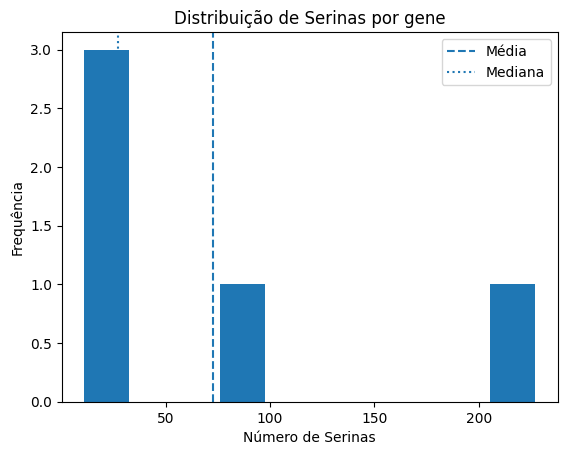

In [49]:
serina = df_final["S"]
media = serina.mean()
mediana = serina.median()

plt.hist(serina)
plt.axvline(media, linestyle="--", label="Média")
plt.axvline(mediana, linestyle=":", label="Mediana")

plt.legend()
plt.title("Distribuição de Serinas por gene")
plt.xlabel("Número de Serinas")
plt.ylabel("Frequência")
plt.show()

## 06 – Defina uma função que receba o nome de um aa qualquer e retorne o mesmo resultado do exercício anterior.

In [52]:
def histograma_aa(df, aa):
    valores = df[aa]
    
    media = valores.mean()
    mediana = valores.median()
    
    plt.hist(valores)
    plt.axvline(media, linestyle="--", label="Média")
    plt.axvline(mediana, linestyle=":", label="Mediana")
    plt.legend()
    plt.title(f"Distribuição de {aa} por gene")
    plt.xlabel(f"Número de {aa}")
    plt.ylabel("Frequência")
    
    plt.show()

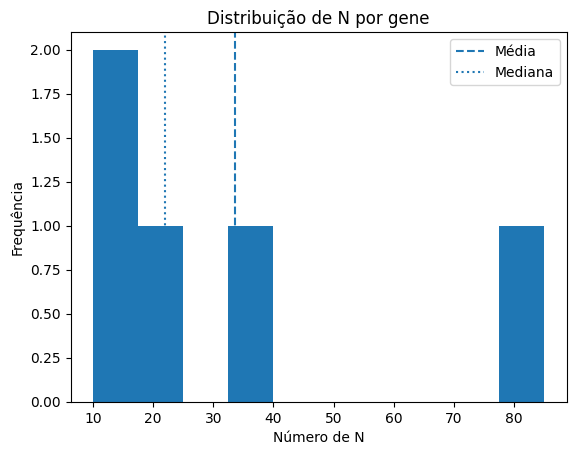

In [57]:
histograma_aa(df_final, "N") #Asparagina

## 07 – Retorne os gráficos dos aa Glutamina, Glicina, Lisina e Valina. Qual possuí menor diferença entre média e mediana?

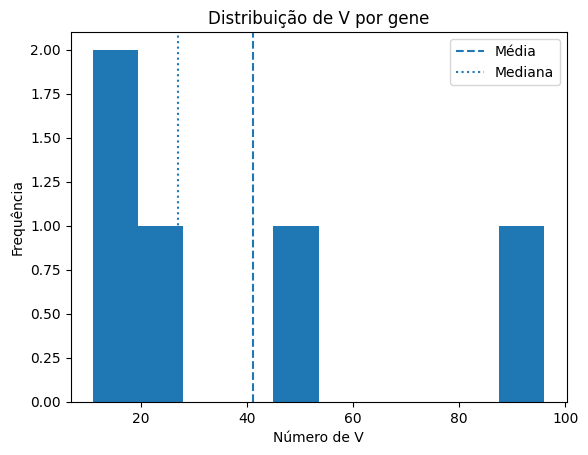

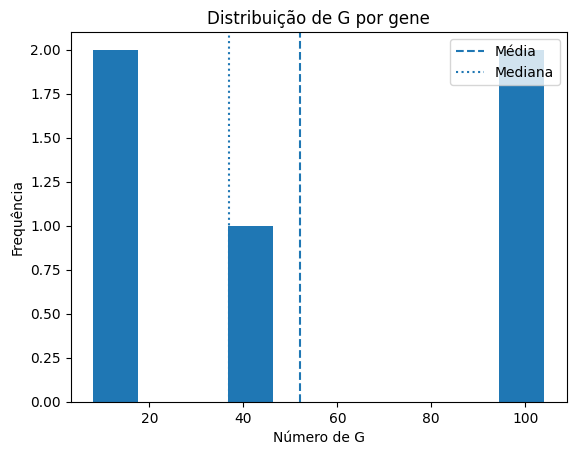

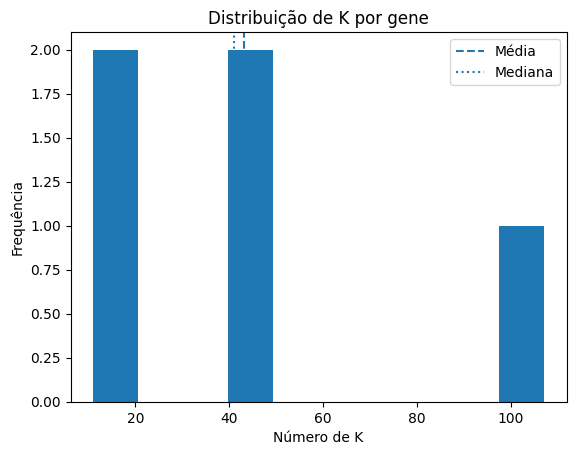

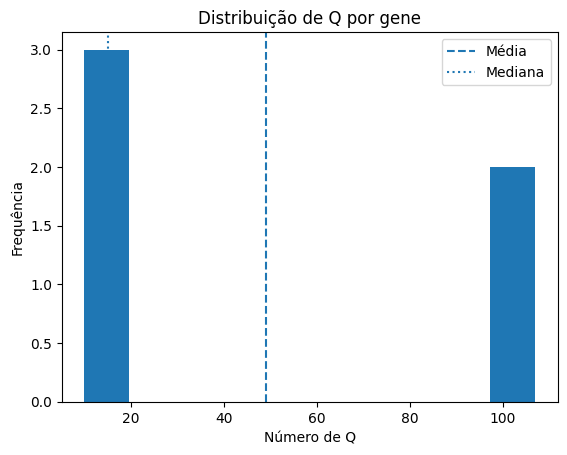

In [58]:
histograma_aa(df_final, "V")  # Valina
histograma_aa(df_final, "G") # Glicina
histograma_aa(df_final, "K") # Lisina
histograma_aa(df_final, "Q") # Glutamina

In [59]:
aas = ["Q", "G", "K", "V"]
resultados = []

for aa in aas:
    media = df_final[aa].mean()
    mediana = df_final[aa].median()
    dif = abs(media - mediana)
    
    resultados.append({
        "aa": aa,
        "media": media,
        "mediana": mediana,
        "diferenca": dif
    })

df_comp = pd.DataFrame(resultados)

df_comp

,aa,media,mediana,diferenca
0,Q,49.0,15.0,34.0
1,G,52.0,37.0,15.0
2,K,43.2,41.0,2.2
3,V,41.2,27.0,14.2


In [64]:
df_menor = df_comp.loc[df_comp["diferenca"].idxmin()]
print("aa com menor diferença:")
df_menor

aa com menor diferença:


aa              K
media        43.2
mediana      41.0
diferenca     2.2
Name: 2, dtype: object

## 08 – Dentre os três primeiros genes, qual é a média e a mediana de Cisteína?

In [66]:
df_3 = df_final.head(3)
df_3

aa,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
gene,,,,,,,,,,,,,,,,,,,,
BRCA1,112,54,95,161,44,104,49,69,107,138,31,85,105,107,97,227,104,96,10,17
HDAC1,26,10,33,48,20,37,14,23,41,31,16,22,21,15,21,27,20,27,2,28
IL6,7,4,12,15,8,8,5,11,16,28,5,14,7,10,11,11,20,11,2,6


In [65]:
df_3 = df_final.head(3)

media = df_3["C"].mean()
mediana = df_3["C"].median()

print("Média:", media)
print("Mediana:", mediana)

Média: 22.666666666666668
Mediana: 10.0


## 09 – Analisando o valor médio de aa em cada um dos genes, qual seria o maior gene (maior número médio de aa)?

In [73]:
df_final["media_aa"] = df_final.mean(axis=1)
maior = df_final.loc[df_final["media_aa"].idxmax()]

print("Gene:", df_final["media_aa"].idxmax())

Gene: BRCA1


## 10 – Olhando o valor médio de aa em cada um dos genes, qual seria o menor gene (menor número médio de aa)?

In [75]:
df_final["media_aa"] = df_final.mean(axis=1)
menor = df_final.loc[df_final["media_aa"].idxmin()]

print("Gene:", df_final["media_aa"].idxmin())

Gene: IL6
